In [ ]:
def budget_mensuel():
    print("=== Calculateur de Budget Mensuel ===")

    salaire = float(input("Salaire mensuel net (€) : "))

    categories = ["Loyer", "Courses", "Transport", "Loisirs", "Autres"]
    depenses = {}

    for cat in categories:
        montant = float(input(f"{cat} (€) : "))
        depenses[cat] = montant
    #on peut aussi faire : 
    #depenses2 = {cat: float(input(f"{cat} (€) : ")) for cat in categories}

    total  = sum(depenses.values())
    solde  = salaire - total

    print("\n--- Récapitulatif ---")
    for cat, m in depenses.items():
        pct = (m / salaire) * 100
        print(f"  {cat:<12} {m:>8.2f} €  ({pct:.1f}%)")

    print(f"\nTotal dépenses : {total:.2f} €")
    print(f"Solde restant  : {solde:.2f} €")

    if solde < 0:
        print("⚠️  Attention : tu dépenses plus que tu ne gagnes !")
    elif solde < salaire * 0.1:
        print("💡 Il reste peu — pense à mettre de côté !")
    else:
        print(f"✅ Bien ! Tu économises {solde:.2f} € ce mois.")

budget_mensuel()

In [4]:
import numpy as np

#Exercice 1
[n1, p1]= input("Ecrivez la taille de votre matrice A")
[n2, p2]= input("Ecrivez la taille de votre matrice B")
print(f"Votre matrice A est de taille [{n1}, {p2}]")



ValueError: too many values to unpack (expected 2)

In [ ]:
#deja fait


import random

def jouer():
    secret  = random.randint(1, 100)
    essais  = 0
    trouve  = False

    print("🎲 J'ai choisi un nombre entre 1 et 100. À toi !")

    while not trouve: #not trouve == True mais not true == False
        tentative = int(input("Ton nombre : "))
        essais += 1

        if   tentative < secret: print("📈 Trop petit !")
        elif tentative > secret: print("📉 Trop grand !")
        else:
            trouve = True
            print(f"🎉 Bravo ! Trouvé en {essais} essai(s) !")

    if   essais <= 5:  print("⭐ Excellent !")
    elif essais <= 10: print("👍 Bien joué !")
    else:              print("💪 Peut mieux faire...")

    return essais

# Bonus : session avec record
record = float("inf")
while True:
    score  = jouer()
    record = min(record, score)
    print(f"🏆 Record session : {record} essai(s)")
    if input("Rejouer ? (o/n) : ").lower() != "o":
        break



In [5]:
import numpy as np

classe = {
    "Alice" : {"Maths":15,"Physique":13,"Info":18,"Anglais":12,"Français":14},
    "Bob"   : {"Maths": 9,"Physique": 7,"Info":11,"Anglais":14,"Français": 8},
    "Clara" : {"Maths":17,"Physique":16,"Info":14,"Anglais":19,"Français":15},
    "Damien": {"Maths":10,"Physique":12,"Info": 9,"Anglais": 7,"Français":11},
}

def calcul_bulletin(nom, notes):
    vals    = np.array(list(notes.values()))
    moyenne = np.mean(vals)
    matieres= list(notes.keys())
    forte   = matieres[np.argmax(vals)]
    faible  = matieres[np.argmin(vals)]
    print(f"\n{'='*35}")
    print(f"  BULLETIN — {nom}")
    print(f"{'='*35}")
    for mat, n in notes.items():
        print(f"  {mat:<12} {n:>4}/20")
    print(f"  {'Moyenne':<12} {moyenne:>5.2f}/20")
    print(f"  ✅ Point fort  : {forte}")
    print(f"  ⚠️  Point faible : {faible}")
    return moyenne

# Génération des bulletins + classement
moyennes = {}
for nom, notes in classe.items():
    moyennes[nom] = calcul_bulletin(nom, notes)

# Classement
classement = sorted(moyennes.items(), key=lambda x: x[1], reverse=True)
#avec get ca donne : classement = sorted(moyennes.items(), key=lambda x: moyennes.get(x[0]), reverse=True)
print("\n🏆 Classement :")
for rang, (nom, moy) in enumerate(classement, 1): #ici enumerate permet de donner un rang à chaque élément du classement, en commençant à 1
    print(f"  {rang}. {nom:<10} {moy:.2f}/20")

# Moyenne par matière (NumPy)
matieres = list(next(iter(classe.values())).keys())
matrice  = np.array([[v for v in n.values()] for n in classe.values()])
print("\n📊 Moyennes par matière :")
for mat, moy in zip(matieres, matrice.mean(axis=0)):
    print(f"  {mat:<12} {moy:.2f}/20")


  BULLETIN — Alice
  Maths          15/20
  Physique       13/20
  Info           18/20
  Anglais        12/20
  Français       14/20
  Moyenne      14.40/20
  ✅ Point fort  : Info
  ⚠️  Point faible : Anglais

  BULLETIN — Bob
  Maths           9/20
  Physique        7/20
  Info           11/20
  Anglais        14/20
  Français        8/20
  Moyenne       9.80/20
  ✅ Point fort  : Anglais
  ⚠️  Point faible : Physique

  BULLETIN — Clara
  Maths          17/20
  Physique       16/20
  Info           14/20
  Anglais        19/20
  Français       15/20
  Moyenne      16.20/20
  ✅ Point fort  : Anglais
  ⚠️  Point faible : Info

  BULLETIN — Damien
  Maths          10/20
  Physique       12/20
  Info            9/20
  Anglais         7/20
  Français       11/20
  Moyenne       9.80/20
  ✅ Point fort  : Physique
  ⚠️  Point faible : Anglais

🏆 Classement :
  1. Clara      16.20/20
  2. Alice      14.40/20
  3. Bob        9.80/20
  4. Damien     9.80/20

📊 Moyennes par matière :
  Maths  

In [4]:
import random
import string

def verifier_mdp(mdp):
    criteres = {
        "Longueur ≥ 8"       : len(mdp) >= 8,
        "Majuscule"          : any(c.isupper() for c in mdp),
        "Minuscule"          : any(c.islower() for c in mdp),
        "Chiffre"            : any(c.isdigit() for c in mdp),
        "Caractère spécial"  : any(c in string.punctuation for c in mdp),
    }
    score  = sum(criteres.values())
    niveaux= ["Très faible", "Faible", "Moyen", "Bon", "Très bon", "Fort"]

    print(f"\n🔐 Analyse de '{mdp}'")
    for crit, ok in criteres.items():
        print(f"  {'✅' if ok else '❌'}  {crit}")
    print(f"\n  Score  : {score}/5 — {niveaux[score]}")
    return score

def generer_mdp(longueur=12):
    chars = (string.ascii_letters + string.digits + "@#$%!&*")
    # Garantir au moins un de chaque type
    mdp = [
        random.choice(string.ascii_uppercase),
        random.choice(string.ascii_lowercase),
        random.choice(string.digits),
        random.choice("@#$%!&*"),
    ]
    mdp += [random.choice(chars) for _ in range(longueur - 4)]
    random.shuffle(mdp)
    return "".join(mdp)

# Test
verifier_mdp("bonjour")
verifier_mdp("Python3#!")
nouveau = generer_mdp()
print(f"\n✨ Mot de passe généré : {nouveau}")
verifier_mdp(nouveau)


🔐 Analyse de 'bonjour'
  ❌  Longueur ≥ 8
  ❌  Majuscule
  ✅  Minuscule
  ❌  Chiffre
  ❌  Caractère spécial

  Score  : 1/5 — Faible

🔐 Analyse de 'Python3#!'
  ✅  Longueur ≥ 8
  ✅  Majuscule
  ✅  Minuscule
  ✅  Chiffre
  ✅  Caractère spécial

  Score  : 5/5 — Fort

✨ Mot de passe généré : %pirXa@0z7KQ

🔐 Analyse de '%pirXa@0z7KQ'
  ✅  Longueur ≥ 8
  ✅  Majuscule
  ✅  Minuscule
  ✅  Chiffre
  ✅  Caractère spécial

  Score  : 5/5 — Fort


5

In [1]:
catalogue = {
    "pomme":0.80, "pain":1.20, "lait":0.95,
    "fromage":3.50, "yaourt":2.10
}

def saisir_panier():
    panier = {}
    print("Articles disponibles :", ", ".join(catalogue.keys()))
    while True:
        article = input("Article (ou 'fin') : ").lower()
        if article == "fin": break
        if article not in catalogue:
            print("❌ Article inconnu."); continue
        qte = int(input(f"Quantité de {article} : "))
        panier[article] = panier.get(article, 0) + qte
    return panier

def ticket(panier):
    print("\n" + "="*42)
    print("        🧾 TICKET DE CAISSE")
    print("="*42)
    print(f"{'Article':<12} {'Qté':>4} {'P.U.':>7} {'Total':>8}")
    print("-"*42)
    sous_total = 0
    for art, qte in panier.items():
        pu    = catalogue[art]
        ligne = pu * qte
        sous_total += ligne
        print(f"{art:<12} {qte:>4} {pu:>7.2f}€ {ligne:>8.2f}€")
    print("="*42)

    remise = sous_total * 0.10 if sous_total > 20 else 0
    net    = sous_total - remise
    tva    = net * 0.055
    ttc    = net + tva

    if remise > 0:
        print(f"{'Sous-total':<22} {sous_total:>8.2f}€")
        print(f"{'Remise 10%':<22} {-remise:>8.2f}€")
    print(f"{'Net HT':<22} {net:>8.2f}€")
    print(f"{'TVA 5.5%':<22} {tva:>8.2f}€")
    print(f"{'TOTAL TTC':<22} {ttc:>8.2f}€")
    print("="*42)

panier = saisir_panier()
if panier:
    ticket(panier)
else:
    print("Panier vide.")

Articles disponibles : pomme, pain, lait, fromage, yaourt
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
❌ Article inconnu.
Panier vide.


In [3]:
import numpy as np

ventes = np.array([
    [120,135,148,162,175,190],
    [ 85, 92, 78, 95, 88,102],
    [200,215,198,220,235,248],
    [ 45, 52, 61, 49, 70, 75],
])

produits = ["Produit A", "Produit B", "Produit C", "Produit D"]
mois     = ["Jan","Fév","Mar","Avr","Mai","Jun"]

# 1. Totaux
total_par_produit = ventes.sum(axis=1)   # somme par ligne
total_par_mois    = ventes.sum(axis=0)   # somme par colonne

print("📦 Total par produit :")
for p, t in zip(produits, total_par_produit):
    print(f"  {p} : {t} unités")

# 2. Meilleur mois et meilleur produit
meilleur_mois    = mois[np.argmax(total_par_mois)]
meilleur_produit = produits[np.argmax(total_par_produit)]
print(f"\n🏆 Meilleur mois    : {meilleur_mois}")
print(f"🥇 Meilleur produit : {meilleur_produit}")

# 3. Croissance mensuelle (%)
#    diff entre mois[i+1] et mois[i], divisé par mois[i]
croissance = ((ventes[:, 1:] - ventes[:, :-1]) / ventes[:, :-1]) * 100
print("\n📈 Croissance mensuelle (%) :")
for p, ligne in zip(produits, croissance):
    vals = "  ".join([f"{v:+.1f}%" for v in ligne])
    print(f"  {p}: {vals}")

# 4. Normalisation min-max
v_min  = ventes.min()
v_max  = ventes.max()
normal = (ventes - v_min) / (v_max - v_min)
print("\n📐 Données normalisées (extrait) :")
print(np.round(normal, 2))

📦 Total par produit :
  Produit A : 930 unités
  Produit B : 540 unités
  Produit C : 1316 unités
  Produit D : 352 unités

🏆 Meilleur mois    : Jun
🥇 Meilleur produit : Produit C

📈 Croissance mensuelle (%) :
  Produit A: +12.5%  +9.6%  +9.5%  +8.0%  +8.6%
  Produit B: +8.2%  -15.2%  +21.8%  -7.4%  +15.9%
  Produit C: +7.5%  -7.9%  +11.1%  +6.8%  +5.5%
  Produit D: +15.6%  +17.3%  -19.7%  +42.9%  +7.1%

📐 Données normalisées (extrait) :
[[0.37 0.44 0.51 0.58 0.64 0.71]
 [0.2  0.23 0.16 0.25 0.21 0.28]
 [0.76 0.84 0.75 0.86 0.94 1.  ]
 [0.   0.03 0.08 0.02 0.12 0.15]]


In [ ]:
import numpy as np

ventes = np.array([
    [120,135,148,162,175,190],
    [ 85, 92, 78, 95, 88,102],
    [200,215,198,220,235,248],
    [ 45, 52, 61, 49, 70, 75],
])

produits = ["Produit A", "Produit B", "Produit C", "Produit D"]
mois     = ["Jan","Fév","Mar","Avr","Mai","Jun"]

# 1. Totaux
total_par_produit = ventes.sum(axis=1)   # somme par ligne
total_par_mois    = ventes.sum(axis=0)   # somme par colonne

print(total_par_produit)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 2*np.pi, 30)#en rouge
y = np.cos(x)
z = np.sin(x) 
plt.plot(x, y,"b x",label="cosinus")
plt.plot(x, z,"r .",label="sinus")
plt.title("Graphique de cos(x) et sin(x)",fontsize=14,color="darkgoldenrod",weight="bold")
plt.xlabel("x (radians)")
plt.ylabel("cos(x) et sin(x)")
plt.legend(loc="upper center")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(0,45,5)#en rouge
y = np.array([15,20,30,35,40,45,50,60,70])#en rouge

plt.plot(x, y,"b",label="temperature")

plt.title("Graphique de temp en fonction de t",fontsize=14,color="darkgoldenrod",weight="bold")
plt.xlabel("temps")
plt.ylabel("temperature")
plt.legend(loc="upper center")
plt.grid(lw=0.2)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 2*np.pi, 30)#en rouge
y = np.cos(x)


plt.plot(x, y)
plt.plot(x, y -0,25)
plt.plot(x, y -0,5)
plt.plot(x, y -0,75)
plt.plot(x, y -1)


plt.show()


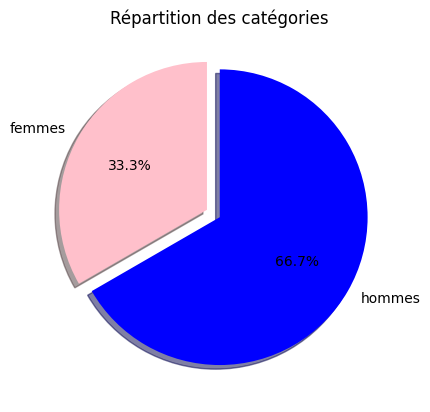

In [3]:
import numpy as np
import matplotlib.pyplot as plt
#diagramme circulaire
labels = ["femmes","hommes"]
tab = [350, 700]
plt.pie(tab, labels=labels,autopct="%1.1f%%", startangle=90, colors=["pink","blue"], explode=[0.1,0],shadow=True)
plt.title("Répartition des catégories")
plt.show()

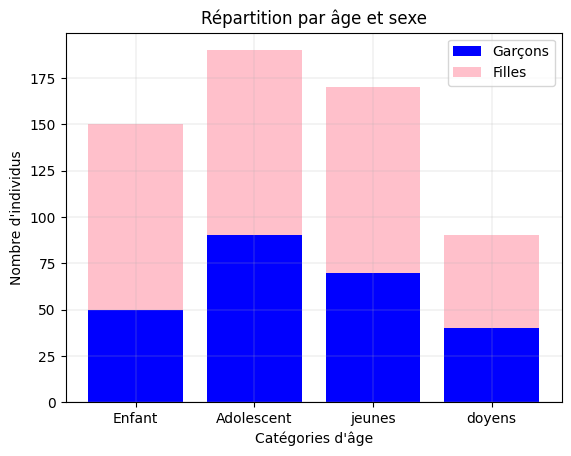

In [6]:
#histogramme
labels = ["Enfant","Adolescent","jeunes","doyens"]
tab = [[50,100],[90,100],[70,100],[40,50]]

plt.bar(labels, [t[0] for t in tab], label="Garçons", color="blue")
plt.bar(labels, [t[1] for t in tab], label="Filles", color="pink", bottom=[t[0] for t in tab])

plt.title("Répartition par âge et sexe")
plt.xlabel("Catégories d'âge")  
plt.grid(lw=0.2)
plt.ylabel("Nombre d'individus")
plt.legend()
plt.show()

[0 1 2 3]
[-0.175  0.825  1.825  2.825]


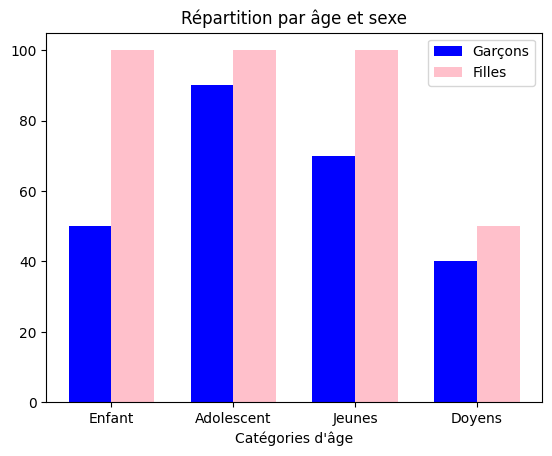

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Histogramme groupé
labels = ["Enfant", "Adolescent", "Jeunes", "Doyens"]
tab = [[50, 100], [90, 100], [70, 100], [40, 50]]

garcons = [t[0] for t in tab]
filles = [t[1] for t in tab]

x = np.arange(len(labels))
width = 0.35
print(x)
print(x - width/2)
plt.bar(x - width/2, garcons, width, label="Garçons", color="blue")
plt.bar(x + width/2, filles, width, label="Filles", color="pink")

plt.title("Répartition par âge et sexe")
plt.xlabel("Catégories d'âge")
plt.xticks(x, labels)
plt.legend()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Histogramme groupé
labels = ["Enfant", "Adolescent", "Jeunes", "Doyens"]
tab = [[50, 100], [90, 100], [70, 100], [40, 50]]

garcons = [t[0] for t in tab]
filles = [t[1] for t in tab]

x = np.arange(len(labels))
width = 0.35
print(x)
print(x - width/2)

[0 1 2 3]
[-0.175  0.825  1.825  2.825]
